# Deep Learning Course - Module 2: Gradient Descent & Optimizers
> **A Comprehensive Hands-On Guide: From Mathematical Foundations to Modern Adaptive Optimizers**

---

## 📌 Executive Overview
Optimization is the core mechanism by which deep learning models learn from data. At its fundamental level, training a neural network corresponds to minimizing a high-dimensional, non-convex loss surface $L(\theta)$ with respect to model parameters $\theta \in \mathbb{R}^d$.

This notebook provides a complete mathematical, intuitive, and practical exploration of optimization algorithms used in modern Deep Learning:

### 📑 Table of Contents
1. **Fundamental Gradient Descent Algorithms**
   - Batch Gradient Descent (BGD)
   - Stochastic Gradient Descent (SGD)
   - Mini-batch Gradient Descent
   - *3D Surface & 2D Contour Convergence Visualizations*
2. **First-Order Momentum Variants**
   - Polyak Momentum
   - Nesterov Accelerated Gradient (NAG)
   - *Navigating Ravines & High-Curvature Landscapes*
3. **Adaptive Learning Rate Optimizers**
   - AdaGrad (Adaptive Gradient Algorithm)
   - RMSprop (Root Mean Square Propagation)
   - Adam (Adaptive Moment Estimation)
   - AdamW (Adam with Decoupled Weight Decay)
   - *Trajectory Analysis on Complex Non-Convex Surfaces*
4. **Learning Rate Schedules**
   - Step Decay
   - Exponential Decay
   - Cosine Annealing
   - ReduceLROnPlateau
5. **Empirical Benchmark on Classification using TensorFlow/Keras**
   - Comparative evaluation of SGD, Momentum, RMSprop, Adam, and AdamW
   - Convergence rate, training/validation loss, and final accuracy analysis

---


In [1]:
# Environment Setup and Global Visual Configuration
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seeds for strict reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure Matplotlib default styling for publication-quality graphics
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 1.0
plt.style.use('seaborn-v0_8-whitegrid')

print(f"NumPy Version: {np.__version__}")
print(f"TensorFlow Version: {tf.__version__}")
print("Global setup complete successfully.")


2026-08-01 06:44:44.877358: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-01 06:44:44.880746: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-01 06:44:44.928154: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-01 06:44:44.928220: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-01 06:44:44.930064: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

2026-08-01 06:44:46.537264: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


NumPy Version: 1.26.4
TensorFlow Version: 2.15.0
Global setup complete successfully.


---
## 1. Fundamental Gradient Descent Algorithms

### 1.1 Mathematical Formulation
Consider a dataset $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^N$ and a model with parameters $\theta$. The empirical risk (loss function) is defined as:
$$L(\theta) = \frac{1}{N} \sum_{i=1}^N \ell(f(x_i; \theta), y_i)$$

The gradient vector $\nabla_\theta L(\theta) \in \mathbb{R}^d$ points in the direction of steepest loss increase. Gradient descent iteratively updates parameters in the opposite direction:
$$\theta_{t+1} = \theta_t - \eta \cdot g_t$$
where $\eta > 0$ is the learning rate and $g_t$ is the estimated gradient at step $t$.

---

### 1.2 Comparison of Gradient Estimation Paradigms

| Optimizer Variant | Batch Size $B$ | Gradient Estimate $g_t$ | Computational Cost per Step | Memory Footprint | Variance of $g_t$ |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Batch Gradient Descent (BGD)** | $N$ (Entire Dataset) | $g_t = \frac{1}{N} \sum_{i=1}^N \nabla_\theta \ell_i(\theta_t)$ | $\mathcal{O}(N \cdot d)$ | High | Zero (Exact) |
| **Stochastic Gradient Descent (SGD)** | $1$ (Single Instance) | $g_t = \nabla_\theta \ell_i(\theta_t), \quad i \sim \text{Uniform}(1..N)$ | $\mathcal{O}(d)$ | Extremely Low | Very High |
| **Mini-batch Gradient Descent** | $1 < B < N$ (Sub-batch) | $g_t = \frac{1}{B} \sum_{k \in \mathcal{B}_t} \nabla_\theta \ell_k(\theta_t)$ | $\mathcal{O}(B \cdot d)$ | Balanced | Moderate |

#### Key Trade-offs:
- **BGD**: Guarantees convergence to local/global minimum on convex surfaces, but becomes computationally intractable for large $N$ ($N > 10^5$) and cannot perform online streaming updates.
- **SGD**: Highly efficient per step and stochastic noise helps jump out of shallow local minima; however, high variance prevents exact convergence without decaying $\eta$.
- **Mini-batch GD**: Leverages vectorization (SIMD/GPU acceleration), significantly reduces variance compared to single-sample SGD, and forms the standard backbone of deep learning optimization.


In [2]:
# Section 1: From-Scratch NumPy Implementation of BGD, SGD, and Mini-batch GD

# Synthetic Linear Regression Dataset setup for parameter trajectory analysis
np.random.seed(42)
N_samples = 1000
true_w = np.array([2.5, -1.5])
X_raw = np.random.randn(N_samples, 2)
# Introduce slight feature correlation to create an elliptical loss landscape
X_raw[:, 1] = 0.6 * X_raw[:, 0] + 0.8 * X_raw[:, 1]
y_raw = X_raw @ true_w + np.random.randn(N_samples) * 0.4

def compute_mse_loss(w, X, y):
    """Compute Mean Squared Error loss L(w) = 0.5 * mean((X w - y)^2)"""
    return 0.5 * np.mean((X @ w - y) ** 2)

def compute_mse_grad(w, X, y):
    """Compute MSE gradient vector wrt w"""
    return X.T @ (X @ w - y) / len(y)

# Initial parameter starting point far from optimal true_w [2.5, -1.5]
w_init = np.array([-1.5, 3.0])
epochs = 40
lr = 0.1

# 1. Batch Gradient Descent (BGD)
w_bgd = w_init.copy()
history_bgd = [w_bgd.copy()]
loss_bgd = [compute_mse_loss(w_bgd, X_raw, y_raw)]

for epoch in range(epochs):
    grad = compute_mse_grad(w_bgd, X_raw, y_raw)
    w_bgd -= lr * grad
    history_bgd.append(w_bgd.copy())
    loss_bgd.append(compute_mse_loss(w_bgd, X_raw, y_raw))

# 2. Stochastic Gradient Descent (SGD, batch size = 1)
w_sgd = w_init.copy()
history_sgd = [w_sgd.copy()]
loss_sgd = [compute_mse_loss(w_sgd, X_raw, y_raw)]
lr_sgd = 0.02 # Lower learning rate to stabilize single-sample updates

for epoch in range(epochs):
    indices = np.random.permutation(N_samples)
    for idx in indices:
        Xi = X_raw[idx:idx+1]
        yi = y_raw[idx:idx+1]
        grad = compute_mse_grad(w_sgd, Xi, yi)
        w_sgd -= lr_sgd * grad
    history_sgd.append(w_sgd.copy())
    loss_sgd.append(compute_mse_loss(w_sgd, X_raw, y_raw))

# 3. Mini-batch Gradient Descent (Batch size = 32)
w_mbgd = w_init.copy()
history_mbgd = [w_mbgd.copy()]
loss_mbgd = [compute_mse_loss(w_mbgd, X_raw, y_raw)]
batch_size = 32

for epoch in range(epochs):
    indices = np.random.permutation(N_samples)
    for i in range(0, N_samples, batch_size):
        batch_idx = indices[i:i+batch_size]
        Xb = X_raw[batch_idx]
        yb = y_raw[batch_idx]
        grad = compute_mse_grad(w_mbgd, Xb, yb)
        w_mbgd -= lr * grad
    history_mbgd.append(w_mbgd.copy())
    loss_mbgd.append(compute_mse_loss(w_mbgd, X_raw, y_raw))

print("Optimization Completed!")
print(f"True Weights      : {true_w}")
print(f"BGD Final Weights : {np.round(w_bgd, 4)} | Final Loss: {loss_bgd[-1]:.5f}")
print(f"SGD Final Weights : {np.round(w_sgd, 4)} | Final Loss: {loss_sgd[-1]:.5f}")
print(f"Mini-batch Final  : {np.round(w_mbgd, 4)} | Final Loss: {loss_mbgd[-1]:.5f}")


Optimization Completed!
True Weights      : [ 2.5 -1.5]
BGD Final Weights : [ 1.658 -0.696] | Final Loss: 0.34871
SGD Final Weights : [ 2.5067 -1.4897] | Final Loss: 0.07722
Mini-batch Final  : [ 2.5187 -1.4761] | Final Loss: 0.07752


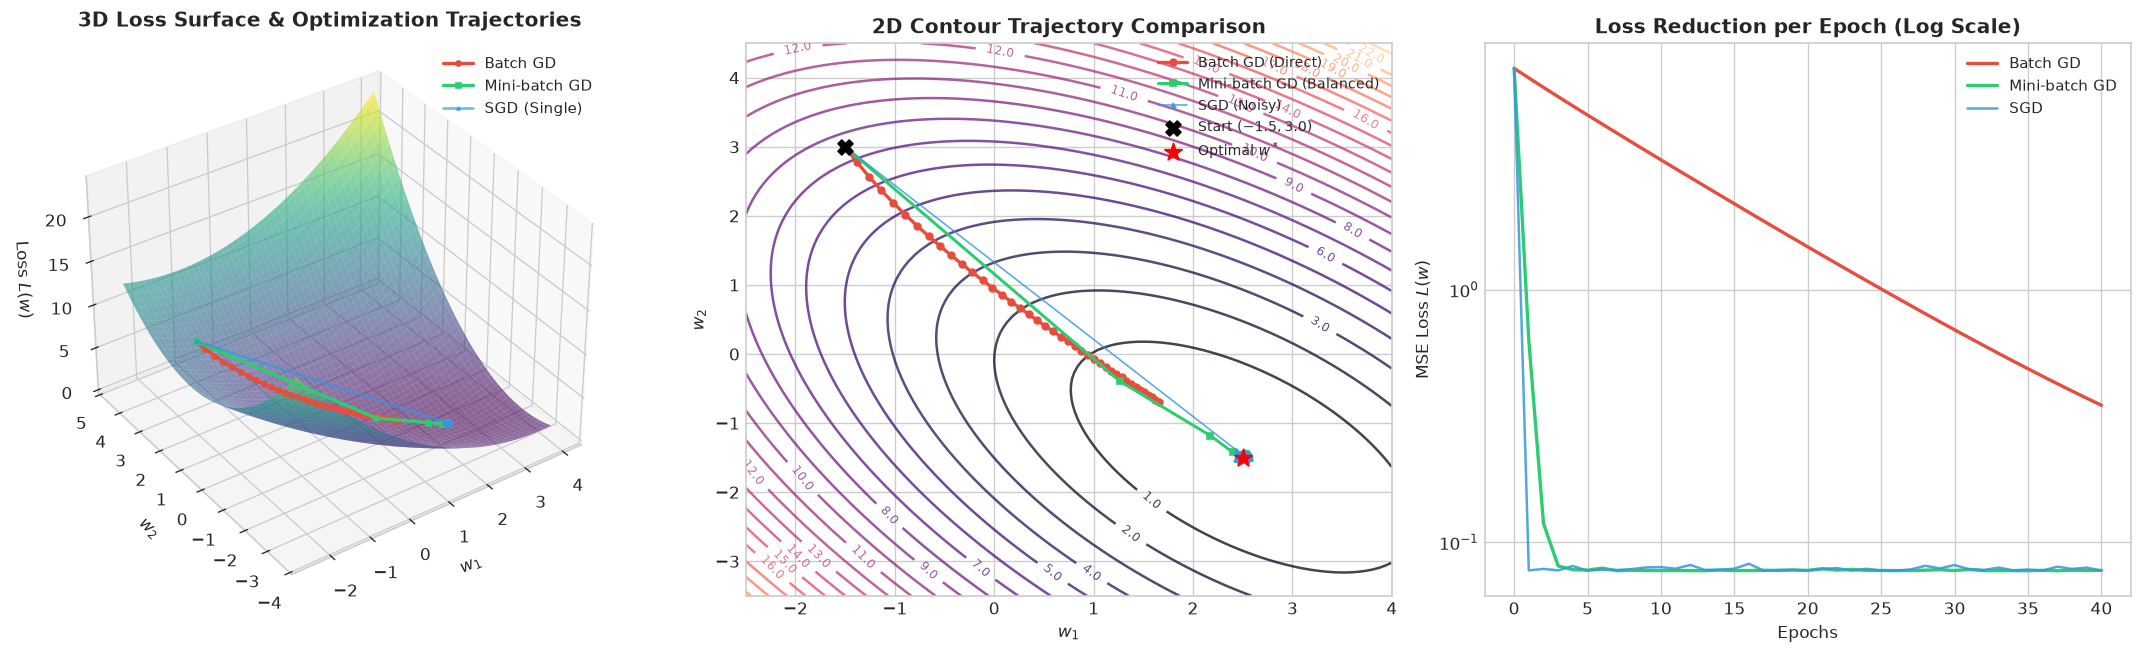

In [3]:
# Section 1 Visualization: 3D Surface, 2D Contour, and Convergence Plot

hist_bgd = np.array(history_bgd)
hist_sgd = np.array(history_sgd)
hist_mbgd = np.array(history_mbgd)

# Construct 2D grid for Loss Surface evaluation
w1_vals = np.linspace(-2.5, 4.0, 100)
w2_vals = np.linspace(-3.5, 4.5, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Z_loss = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w_ij = np.array([W1[i, j], W2[i, j]])
        Z_loss[i, j] = compute_mse_loss(w_ij, X_raw, y_raw)

fig = plt.figure(figsize=(18, 5.5))

# Subplot 1: 3D Loss Surface Plot
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
surf = ax1.plot_surface(W1, W2, Z_loss, cmap='viridis', alpha=0.6, edgecolor='none')
z_bgd = [compute_mse_loss(w, X_raw, y_raw) for w in hist_bgd]
z_sgd = [compute_mse_loss(w, X_raw, y_raw) for w in hist_sgd]
z_mbgd = [compute_mse_loss(w, X_raw, y_raw) for w in hist_mbgd]

ax1.plot(hist_bgd[:, 0], hist_bgd[:, 1], z_bgd, color='#e74c3c', marker='o', markersize=3, label='Batch GD', linewidth=2)
ax1.plot(hist_mbgd[:, 0], hist_mbgd[:, 1], z_mbgd, color='#2ecc71', marker='s', markersize=3, label='Mini-batch GD', linewidth=2)
ax1.plot(hist_sgd[:, 0], hist_sgd[:, 1], z_sgd, color='#3498db', marker='^', markersize=2, label='SGD (Single)', alpha=0.7)

ax1.set_title("3D Loss Surface & Optimization Trajectories", fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel("$w_1$")
ax1.set_ylabel("$w_2$")
ax1.set_zlabel("Loss $L(w)$")
ax1.view_init(elev=35, azim=-125)
ax1.legend(loc='upper right', fontsize=9)

# Subplot 2: 2D Contour Map
ax2 = fig.add_subplot(1, 3, 2)
contour = ax2.contour(W1, W2, Z_loss, levels=25, cmap='magma', alpha=0.75)
ax2.clabel(contour, inline=True, fontsize=7, fmt='%.1f')

ax2.plot(hist_bgd[:, 0], hist_bgd[:, 1], 'o-', color='#e74c3c', label='Batch GD (Direct)', linewidth=2, markersize=4)
ax2.plot(hist_mbgd[:, 0], hist_mbgd[:, 1], 's-', color='#2ecc71', label='Mini-batch GD (Balanced)', linewidth=1.8, markersize=4)
ax2.plot(hist_sgd[:, 0], hist_sgd[:, 1], '^-', color='#3498db', label='SGD (Noisy)', linewidth=1.0, markersize=3, alpha=0.8)

ax2.scatter(w_init[0], w_init[1], color='black', s=80, zorder=5, marker='X', label='Start $(-1.5, 3.0)$')
ax2.scatter(true_w[0], true_w[1], color='red', s=120, zorder=5, marker='*', label='Optimal $w^*$')

ax2.set_title("2D Contour Trajectory Comparison", fontsize=12, fontweight='bold')
ax2.set_xlabel("$w_1$")
ax2.set_ylabel("$w_2$")
ax2.legend(loc='upper right', fontsize=8.5)

# Subplot 3: Loss vs Epochs
ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(range(len(loss_bgd)), loss_bgd, color='#e74c3c', label='Batch GD', linewidth=2)
ax3.plot(range(len(loss_mbgd)), loss_mbgd, color='#2ecc71', label='Mini-batch GD', linewidth=2)
ax3.plot(range(len(loss_sgd)), loss_sgd, color='#3498db', label='SGD', linewidth=1.5, alpha=0.85)

ax3.set_yscale('log')
ax3.set_title("Loss Reduction per Epoch (Log Scale)", fontsize=12, fontweight='bold')
ax3.set_xlabel("Epochs")
ax3.set_ylabel("MSE Loss $L(w)$")
ax3.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


---
## 2. First-Order Momentum Variants

### 2.1 The Ravine / Pathological Curvature Problem
In many deep learning loss landscapes, the surface bends much more steeply in one direction than in another. Such regions are called **ravines** or **ill-conditioned surfaces** (characterized by a high condition number $\kappa = \frac{\lambda_{\max}(H)}{\lambda_{\min}(H)}$ of the Hessian matrix $H$).

Standard Gradient Descent oscillates wildly across the steep slopes while making agonizingly slow progress along the bottom of the ravine toward the minimum.

---

### 2.2 Polyak Momentum
To accelerate learning in ravines, Polyak Momentum introduces a **velocity vector** $v_t$ that accumulates past gradients with an exponential decay factor $\gamma \in [0, 1)$ (typically $\gamma = 0.9$):

$$v_t = \gamma v_{t-1} + \eta \nabla_\theta L(\theta_t)$$
$$\theta_{t+1} = \theta_t - v_t$$

#### Physical Analogy:
Think of a heavy iron ball rolling down a hilly landscape. The momentum component $\gamma v_{t-1}$ maintains velocity in directions of consistent gradients, while opposing components in oscillating directions cancel out.

---

### 2.3 Nesterov Accelerated Gradient (NAG)
NAG improves upon Polyak momentum by introducing a **"look-ahead"** gradient computation. Instead of calculating the gradient at the current position $\theta_t$, NAG computes the gradient at the predicted future position $\theta_t - \gamma v_{t-1}$:

$$v_t = \gamma v_{t-1} + \eta \nabla_\theta L(\theta_t - \gamma v_{t-1})$$
$$\theta_{t+1} = \theta_t - v_t$$

#### Mathematical Intuition:
By estimating where the momentum vector will take the parameters next, NAG detects when the parameter trajectory is overshooting or going uphill, applying a braking force before arriving at the turning point.


In [4]:
# Section 2: Implementation of Standard SGD, Polyak Momentum, and NAG

# Define an Elongated Ravine Quadratic Loss Surface: f(x, y) = 0.05 * x^2 + 2.5 * y^2
# Curvature ratio (Hessian condition number) = 2.5 / 0.05 = 50

def ravine_loss(pos):
    x, y = pos[0], pos[1]
    return 0.05 * x**2 + 2.5 * y**2

def ravine_grad(pos):
    x, y = pos[0], pos[1]
    return np.array([0.1 * x, 5.0 * y])

pos_init = np.array([-4.5, 3.5])
steps = 60
lr_ravine = 0.18
gamma = 0.85

# 1. Standard SGD
pos_sgd = pos_init.copy()
hist_ravine_sgd = [pos_sgd.copy()]
loss_ravine_sgd = [ravine_loss(pos_sgd)]

for _ in range(steps):
    g = ravine_grad(pos_sgd)
    pos_sgd -= lr_ravine * g
    hist_ravine_sgd.append(pos_sgd.copy())
    loss_ravine_sgd.append(ravine_loss(pos_sgd))

# 2. Polyak Momentum
pos_mom = pos_init.copy()
v_mom = np.zeros(2)
hist_ravine_mom = [pos_mom.copy()]
loss_ravine_mom = [ravine_loss(pos_mom)]

for _ in range(steps):
    g = ravine_grad(pos_mom)
    v_mom = gamma * v_mom + lr_ravine * g
    pos_mom -= v_mom
    hist_ravine_mom.append(pos_mom.copy())
    loss_ravine_mom.append(ravine_loss(pos_mom))

# 3. Nesterov Accelerated Gradient (NAG)
pos_nag = pos_init.copy()
v_nag = np.zeros(2)
hist_ravine_nag = [pos_nag.copy()]
loss_ravine_nag = [ravine_loss(pos_nag)]

for _ in range(steps):
    # Look-ahead point computation
    pos_lookahead = pos_nag - gamma * v_nag
    g_lookahead = ravine_grad(pos_lookahead)
    v_nag = gamma * v_nag + lr_ravine * g_lookahead
    pos_nag -= v_nag
    hist_ravine_nag.append(pos_nag.copy())
    loss_ravine_nag.append(ravine_loss(pos_nag))

print("Ravine Optimization Completed!")
print(f"SGD Final Pos  : {np.round(pos_sgd, 4)} | Final Loss: {loss_ravine_sgd[-1]:.6f}")
print(f"Momentum Final : {np.round(pos_mom, 4)} | Final Loss: {loss_ravine_mom[-1]:.6f}")
print(f"NAG Final Pos  : {np.round(pos_nag, 4)} | Final Loss: {loss_ravine_nag[-1]:.6f}")


Ravine Optimization Completed!
SGD Final Pos  : [-1.5132  0.    ] | Final Loss: 0.114492
Momentum Final : [-0.0406  0.0241] | Final Loss: 0.001538
NAG Final Pos  : [-0.0221  0.    ] | Final Loss: 0.000024


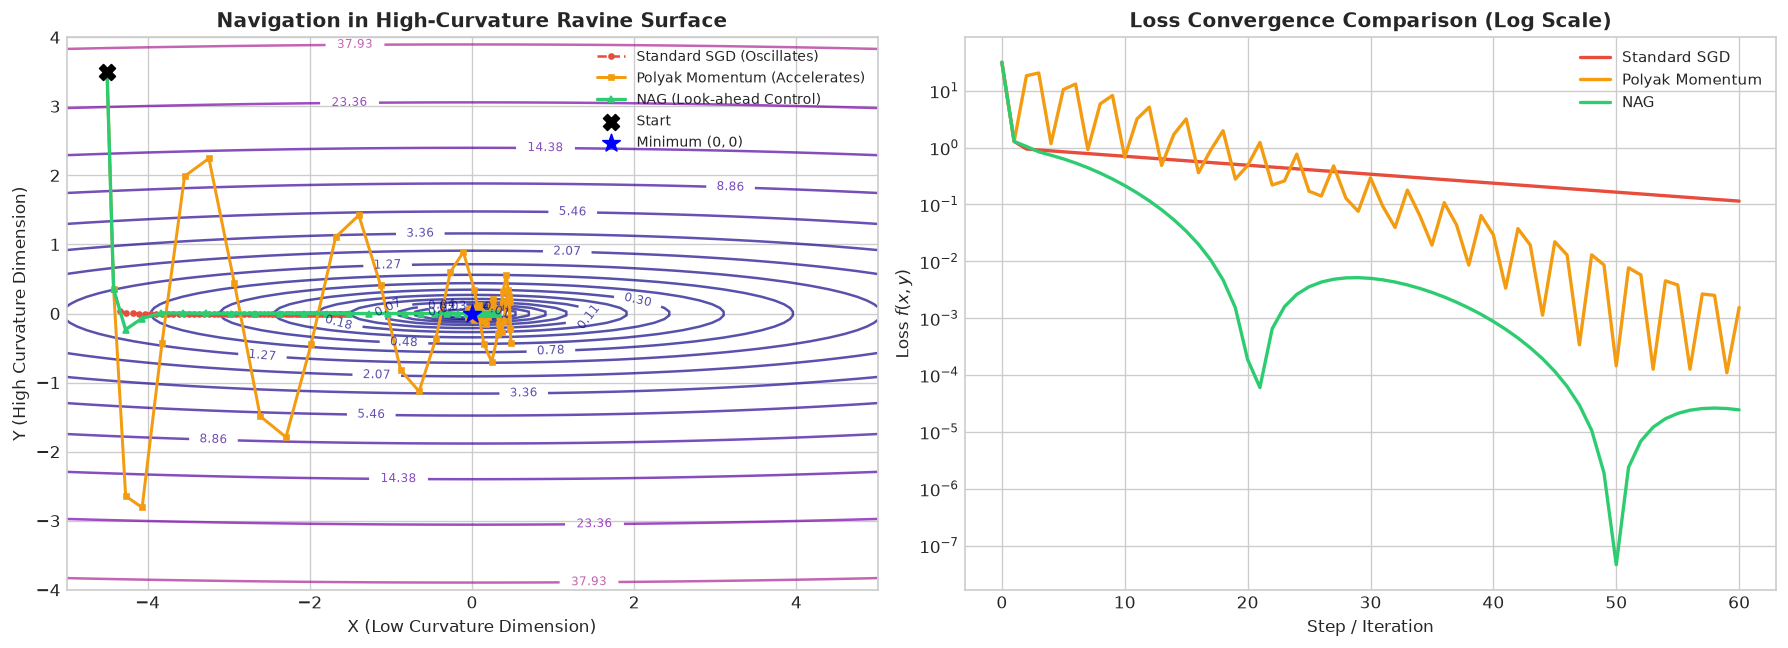

In [5]:
# Section 2 Visualizations: Contour Map of Ravine & Convergence Comparison

hist_ravine_sgd = np.array(hist_ravine_sgd)
hist_ravine_mom = np.array(hist_ravine_mom)
hist_ravine_nag = np.array(hist_ravine_nag)

x_vals = np.linspace(-5.0, 5.0, 150)
y_vals = np.linspace(-4.0, 4.0, 150)
X_rav, Y_rav = np.meshgrid(x_vals, y_vals)
Z_rav = 0.05 * X_rav**2 + 2.5 * Y_rav**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Contour Plot
contour = ax1.contour(X_rav, Y_rav, Z_rav, levels=np.logspace(-2, 2, 20), cmap='plasma', alpha=0.7)
ax1.clabel(contour, inline=True, fontsize=7, fmt='%.2f')

ax1.plot(hist_ravine_sgd[:, 0], hist_ravine_sgd[:, 1], 'o--', color='#e74c3c', label='Standard SGD (Oscillates)', linewidth=1.5, markersize=3)
ax1.plot(hist_ravine_mom[:, 0], hist_ravine_mom[:, 1], 's-', color='#f39c12', label='Polyak Momentum (Accelerates)', linewidth=1.8, markersize=3)
ax1.plot(hist_ravine_nag[:, 0], hist_ravine_nag[:, 1], '^-', color='#2ecc71', label='NAG (Look-ahead Control)', linewidth=2.0, markersize=4)

ax1.scatter(pos_init[0], pos_init[1], color='black', s=90, zorder=5, marker='X', label='Start')
ax1.scatter(0, 0, color='blue', s=120, zorder=5, marker='*', label='Minimum $(0, 0)$')

ax1.set_title("Navigation in High-Curvature Ravine Surface", fontsize=12, fontweight='bold')
ax1.set_xlabel("X (Low Curvature Dimension)")
ax1.set_ylabel("Y (High Curvature Dimension)")
ax1.legend(loc='upper right', fontsize=8.5)

# Loss Convergence
ax2.plot(range(len(loss_ravine_sgd)), loss_ravine_sgd, color='#e74c3c', label='Standard SGD', linewidth=2)
ax2.plot(range(len(loss_ravine_mom)), loss_ravine_mom, color='#f39c12', label='Polyak Momentum', linewidth=2)
ax2.plot(range(len(loss_ravine_nag)), loss_ravine_nag, color='#2ecc71', label='NAG', linewidth=2)

ax2.set_yscale('log')
ax2.set_title("Loss Convergence Comparison (Log Scale)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Step / Iteration")
ax2.set_ylabel("Loss $f(x, y)$")
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


---
## 3. Adaptive Learning Rate Optimizers

Uniform learning rates treat all parameters identically. However, deep neural networks feature sparse features, heterogeneous gradient scales, and varying parameter sensitivities across layers. Adaptive optimizers dynamically compute individual learning rates for each parameter.

---

### 3.1 AdaGrad (Adaptive Gradient Algorithm)
AdaGrad accumulates the sum of squared historical gradients for each parameter:

$$s_t = s_{t-1} + g_t \odot g_t$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_t} + \epsilon} \odot g_t$$

- **Pros**: Automatically lowers learning rate for frequently updated parameters and increases it for infrequent parameters.
- **Flaw**: $s_t$ grows monotonically without bound, causing the effective step size $\frac{\eta}{\sqrt{s_t} + \epsilon} \to 0$, prematurely stopping learning.

---

### 3.2 RMSprop (Root Mean Square Propagation)
RMSprop fixes AdaGrad's flaw by replacing cumulative summation with an **Exponential Moving Average (EMA)** of squared gradients:

$$s_t = \beta s_{t-1} + (1 - \beta) g_t^2, \quad \beta \in [0.9, 0.99]$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_t} + \epsilon} \odot g_t$$

By decaying historical gradients, RMSprop retains sensitivity to recent gradient magnitudes and avoids diminishing step sizes.

---

### 3.3 Adam (Adaptive Moment Estimation)
Adam combines the principles of **Momentum** (1st moment $m_t$) and **RMSprop** (2nd uncentered moment $v_t$):

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \quad (\text{First Moment / Velocity})$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \quad (\text{Second Moment / Squared Scale})$$

#### Bias Correction:
Since $m_0 = 0$ and $v_0 = 0$, $m_t$ and $v_t$ are biased toward zero in initial iterations. Adam corrects this using:
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - eta_2^t}$$

#### Update Rule:
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \odot \hat{m}_t$$

Default Hyperparameters: $\eta = 0.001, \beta_1 = 0.9, \beta_2 = 0.999, \epsilon = 10^{-8}$.

---

### 3.4 AdamW (Decoupled Weight Decay)
In standard Adam with L2 regularization ($g_t' = g_t + \lambda \theta_t$), the regularization gradient is divided by $\sqrt{\hat{v}_t}$. Parameters with large historical gradients receive disproportionately *smaller* weight decay updates than parameters with small gradients!

AdamW decouples weight decay $\lambda$ from gradient scaling:

$$\theta_{t+1} = (1 - \eta \lambda) \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \odot \hat{m}_t$$

This restores standard L2 regularization dynamics and improves generalization significantly in vision and language transformers.


In [6]:
# Section 3: NumPy Implementations of AdaGrad, RMSprop, Adam, and AdamW

# Rosenbrock Banana Function: f(x, y) = (1 - x)^2 + 100 * (y - x^2)^2
# Global Minimum at (1.0, 1.0) with loss = 0.0

def rosenbrock_loss(pos):
    x, y = pos[0], pos[1]
    return (1.0 - x)**2 + 100.0 * (y - x**2)**2

def rosenbrock_grad(pos):
    x, y = pos[0], pos[1]
    dx = -2.0 * (1.0 - x) - 400.0 * x * (y - x**2)
    dy = 200.0 * (y - x**2)
    return np.array([dx, dy])

pos_start = np.array([-1.2, 1.5])
steps_adapt = 250

# 1. AdaGrad Implementation
def run_adagrad(pos_init, lr=0.4, eps=1e-8):
    pos = pos_init.copy()
    s = np.zeros_like(pos)
    history, losses = [pos.copy()], [rosenbrock_loss(pos)]
    for _ in range(steps_adapt):
        g = rosenbrock_grad(pos)
        s += g**2
        pos -= (lr / (np.sqrt(s) + eps)) * g
        history.append(pos.copy())
        losses.append(rosenbrock_loss(pos))
    return np.array(history), losses

# 2. RMSprop Implementation
def run_rmsprop(pos_init, lr=0.015, beta=0.9, eps=1e-8):
    pos = pos_init.copy()
    s = np.zeros_like(pos)
    history, losses = [pos.copy()], [rosenbrock_loss(pos)]
    for _ in range(steps_adapt):
        g = rosenbrock_grad(pos)
        s = beta * s + (1.0 - beta) * (g**2)
        pos -= (lr / (np.sqrt(s) + eps)) * g
        history.append(pos.copy())
        losses.append(rosenbrock_loss(pos))
    return np.array(history), losses

# 3. Adam Implementation
def run_adam(pos_init, lr=0.03, beta1=0.9, beta2=0.999, eps=1e-8):
    pos = pos_init.copy()
    m = np.zeros_like(pos)
    v = np.zeros_like(pos)
    history, losses = [pos.copy()], [rosenbrock_loss(pos)]
    for t in range(1, steps_adapt + 1):
        g = rosenbrock_grad(pos)
        m = beta1 * m + (1.0 - beta1) * g
        v = beta2 * v + (1.0 - beta2) * (g**2)
        m_hat = m / (1.0 - beta1**t)
        v_hat = v / (1.0 - beta2**t)
        pos -= (lr / (np.sqrt(v_hat) + eps)) * m_hat
        history.append(pos.copy())
        losses.append(rosenbrock_loss(pos))
    return np.array(history), losses

# 4. AdamW Implementation (with weight decay lambda = 0.01)
def run_adamw(pos_init, lr=0.03, beta1=0.9, beta2=0.999, weight_decay=0.01, eps=1e-8):
    pos = pos_init.copy()
    m = np.zeros_like(pos)
    v = np.zeros_like(pos)
    history, losses = [pos.copy()], [rosenbrock_loss(pos)]
    for t in range(1, steps_adapt + 1):
        g = rosenbrock_grad(pos)
        # Decoupled weight decay step applied directly to parameter vector
        pos = pos * (1.0 - lr * weight_decay)
        m = beta1 * m + (1.0 - beta1) * g
        v = beta2 * v + (1.0 - beta2) * (g**2)
        m_hat = m / (1.0 - beta1**t)
        v_hat = v / (1.0 - beta2**t)
        pos -= (lr / (np.sqrt(v_hat) + eps)) * m_hat
        history.append(pos.copy())
        losses.append(rosenbrock_loss(pos))
    return np.array(history), losses

# Execute all adaptive optimizers
hist_adagrad, loss_adagrad = run_adagrad(pos_start)
hist_rmsprop, loss_rmsprop = run_rmsprop(pos_start)
hist_adam, loss_adam = run_adam(pos_start)
hist_adamw, loss_adamw = run_adamw(pos_start)

print("Adaptive Optimizers Run Complete!")
print(f"AdaGrad Final Pos: {np.round(hist_adagrad[-1], 4)} | Final Loss: {loss_adagrad[-1]:.5f}")
print(f"RMSprop Final Pos: {np.round(hist_rmsprop[-1], 4)} | Final Loss: {loss_rmsprop[-1]:.5f}")
print(f"Adam Final Pos   : {np.round(hist_adam[-1], 4)} | Final Loss: {loss_adam[-1]:.5f}")
print(f"AdamW Final Pos  : {np.round(hist_adamw[-1], 4)} | Final Loss: {loss_adamw[-1]:.5f}")


Adaptive Optimizers Run Complete!
AdaGrad Final Pos: [-1.0408  1.0889] | Final Loss: 4.16802
RMSprop Final Pos: [-0.5796  0.356 ] | Final Loss: 2.53548
Adam Final Pos   : [0.651  0.4226] | Final Loss: 0.12193
AdamW Final Pos  : [0.6561 0.4294] | Final Loss: 0.11838


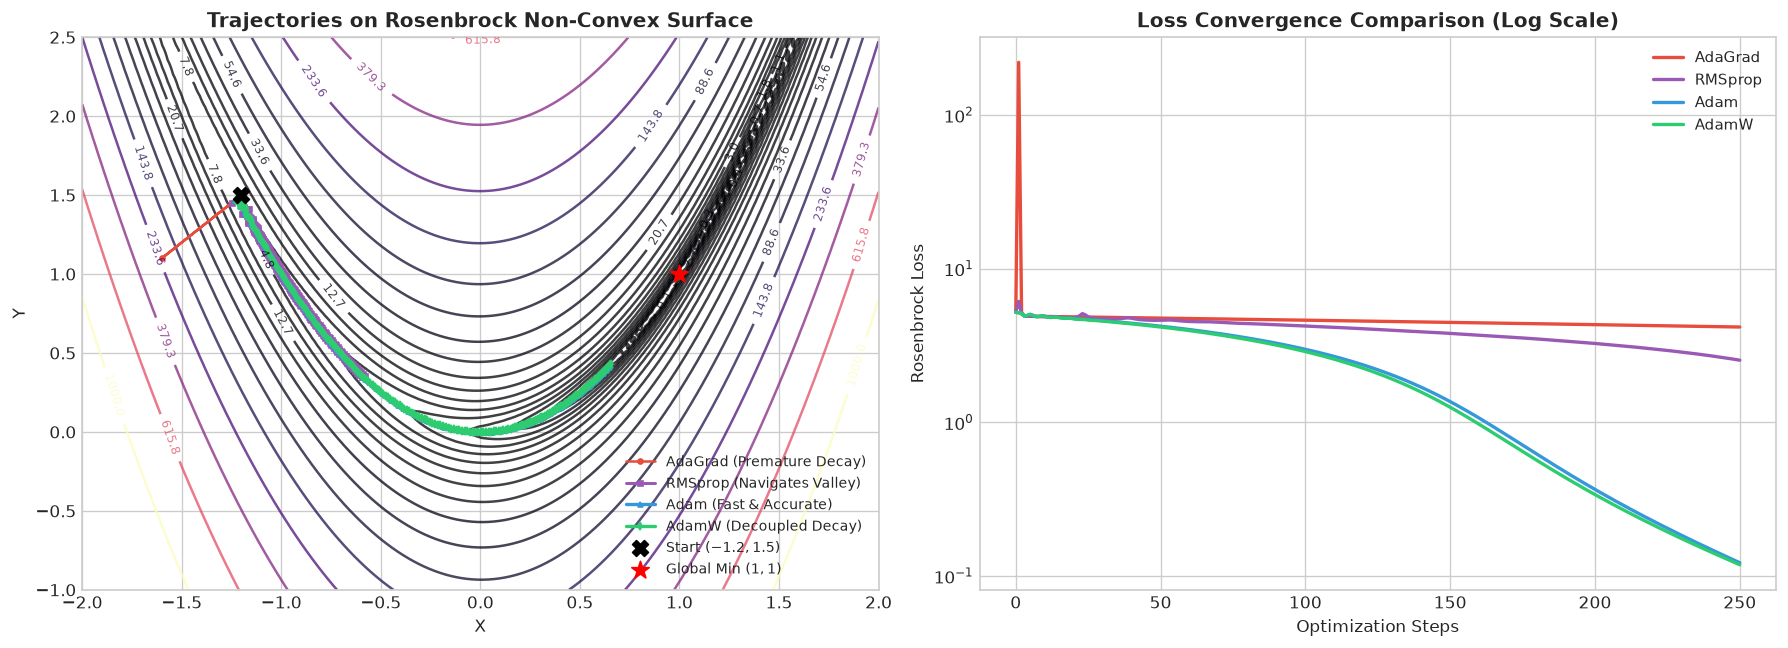

In [7]:
# Section 3 Visualizations: Trajectories on Rosenbrock Banana Surface

rx_vals = np.linspace(-2.0, 2.0, 150)
ry_vals = np.linspace(-1.0, 2.5, 150)
RX, RY = np.meshgrid(rx_vals, ry_vals)
RZ = (1.0 - RX)**2 + 100.0 * (RY - RX**2)**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Contour Plot
contour = ax1.contour(RX, RY, RZ, levels=np.logspace(-1, 3, 20), cmap='magma', alpha=0.75)
ax1.clabel(contour, inline=True, fontsize=7, fmt='%.1f')

ax1.plot(hist_adagrad[:, 0], hist_adagrad[:, 1], 'o-', color='#e74c3c', label='AdaGrad (Premature Decay)', linewidth=1.5, markersize=3)
ax1.plot(hist_rmsprop[:, 0], hist_rmsprop[:, 1], 's-', color='#9b59b6', label='RMSprop (Navigates Valley)', linewidth=1.8, markersize=3)
ax1.plot(hist_adam[:, 0], hist_adam[:, 1], '^-', color='#3498db', label='Adam (Fast & Accurate)', linewidth=2.0, markersize=3)
ax1.plot(hist_adamw[:, 0], hist_adamw[:, 1], 'd-', color='#2ecc71', label='AdamW (Decoupled Decay)', linewidth=2.0, markersize=3)

ax1.scatter(pos_start[0], pos_start[1], color='black', s=90, zorder=5, marker='X', label='Start $(-1.2, 1.5)$')
ax1.scatter(1.0, 1.0, color='red', s=120, zorder=5, marker='*', label='Global Min $(1, 1)$')

ax1.set_title("Trajectories on Rosenbrock Non-Convex Surface", fontsize=12, fontweight='bold')
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.legend(loc='lower right', fontsize=8.5)

# Loss Convergence
ax2.plot(range(len(loss_adagrad)), loss_adagrad, color='#e74c3c', label='AdaGrad', linewidth=2)
ax2.plot(range(len(loss_rmsprop)), loss_rmsprop, color='#9b59b6', label='RMSprop', linewidth=2)
ax2.plot(range(len(loss_adam)), loss_adam, color='#3498db', label='Adam', linewidth=2)
ax2.plot(range(len(loss_adamw)), loss_adamw, color='#2ecc71', label='AdamW', linewidth=2)

ax2.set_yscale('log')
ax2.set_title("Loss Convergence Comparison (Log Scale)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Optimization Steps")
ax2.set_ylabel("Rosenbrock Loss")
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


---
## 4. Learning Rate Schedules

Selecting a fixed learning rate $\eta$ presents a dilemma:
- Too high $\eta$: Fast initial progress, but oscillates around or diverges from the minimum.
- Too low $\eta$: Stable convergence, but extremely slow training and risk of getting stuck in local minima.

**Learning Rate Schedules** adjust $\eta$ over the course of training epochs $t$.

---

### 4.1 Step Decay
Reduces learning rate by a drop factor $\gamma \in (0, 1)$ every $E$ epochs:
$$\eta(t) = \eta_0 \cdot \gamma^{\lfloor t / E \rfloor}$$

### 4.2 Exponential Decay
Smoothly decreases learning rate exponentially per epoch with decay rate $k$:
$$\eta(t) = \eta_0 \cdot e^{-k t}$$

### 4.3 Cosine Annealing
Decreases learning rate following a cosine curve from $\eta_{\max}$ to $\eta_{\min}$ over total epochs $T_{\max}$:
$$\eta(t) = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min}) \left(1 + \cos\left(\frac{t}{T_{\max}}\pi\right)\right)$$

### 4.4 ReduceLROnPlateau
Monitors a validation metric (e.g., validation loss). When the metric stops improving for a specified `patience` number of epochs, the learning rate is reduced by a factor $\gamma$:
$$\eta_{t+1} = \begin{cases} \eta_t \cdot \gamma & \text{if } \text{val\_loss} \text{ fails to improve for } P \text{ epochs} \\ \eta_t & \text{otherwise} \end{cases}$$


In [8]:
# Section 4: Implementation and Simulation of Learning Rate Schedules

total_epochs = 100
initial_lr = 0.1

# 1. Step Decay Function
def get_step_decay(epoch, lr_0=initial_lr, drop=0.5, epochs_drop=20):
    return lr_0 * (drop ** np.floor(epoch / epochs_drop))

# 2. Exponential Decay Function
def get_exp_decay(epoch, lr_0=initial_lr, k=0.035):
    return lr_0 * np.exp(-k * epoch)

# 3. Cosine Annealing Function
def get_cosine_annealing(epoch, lr_max=initial_lr, lr_min=0.001, T_max=total_epochs):
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * epoch / T_max))

# 4. ReduceLROnPlateau Class Simulator
class ReduceLROnPlateauSimulator:
    def __init__(self, init_lr=initial_lr, factor=0.5, patience=8, min_lr=1e-4):
        self.lr = init_lr
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.best_loss = float('inf')
        self.wait = 0
        
    def step(self, val_loss):
        if val_loss < self.best_loss - 1e-4:
            self.best_loss = val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.lr = max(self.lr * self.factor, self.min_lr)
                self.wait = 0
        return self.lr

# Simulate learning rate schedules over 100 epochs
epochs_range = np.arange(total_epochs)
lrs_step = [get_step_decay(e) for e in epochs_range]
lrs_exp = [get_exp_decay(e) for e in epochs_range]
lrs_cosine = [get_cosine_annealing(e) for e in epochs_range]

# Simulate realistic Validation Loss curve (fast decay early, plateaus around epoch 25 and 55)
simulated_val_loss = 0.8 * np.exp(-0.08 * epochs_range) + 0.15 + 0.02 * np.random.randn(total_epochs)
# Smooth the noise
simulated_val_loss = np.convolve(simulated_val_loss, np.ones(3)/3, mode='same')
simulated_val_loss[30:50] += 0.02 # Force plateau
simulated_val_loss[65:] += 0.03

plateau_sim = ReduceLROnPlateauSimulator(init_lr=initial_lr, factor=0.5, patience=8)
lrs_plateau = [plateau_sim.step(loss) for loss in simulated_val_loss]

print("LR Schedules Simulation Complete!")


LR Schedules Simulation Complete!


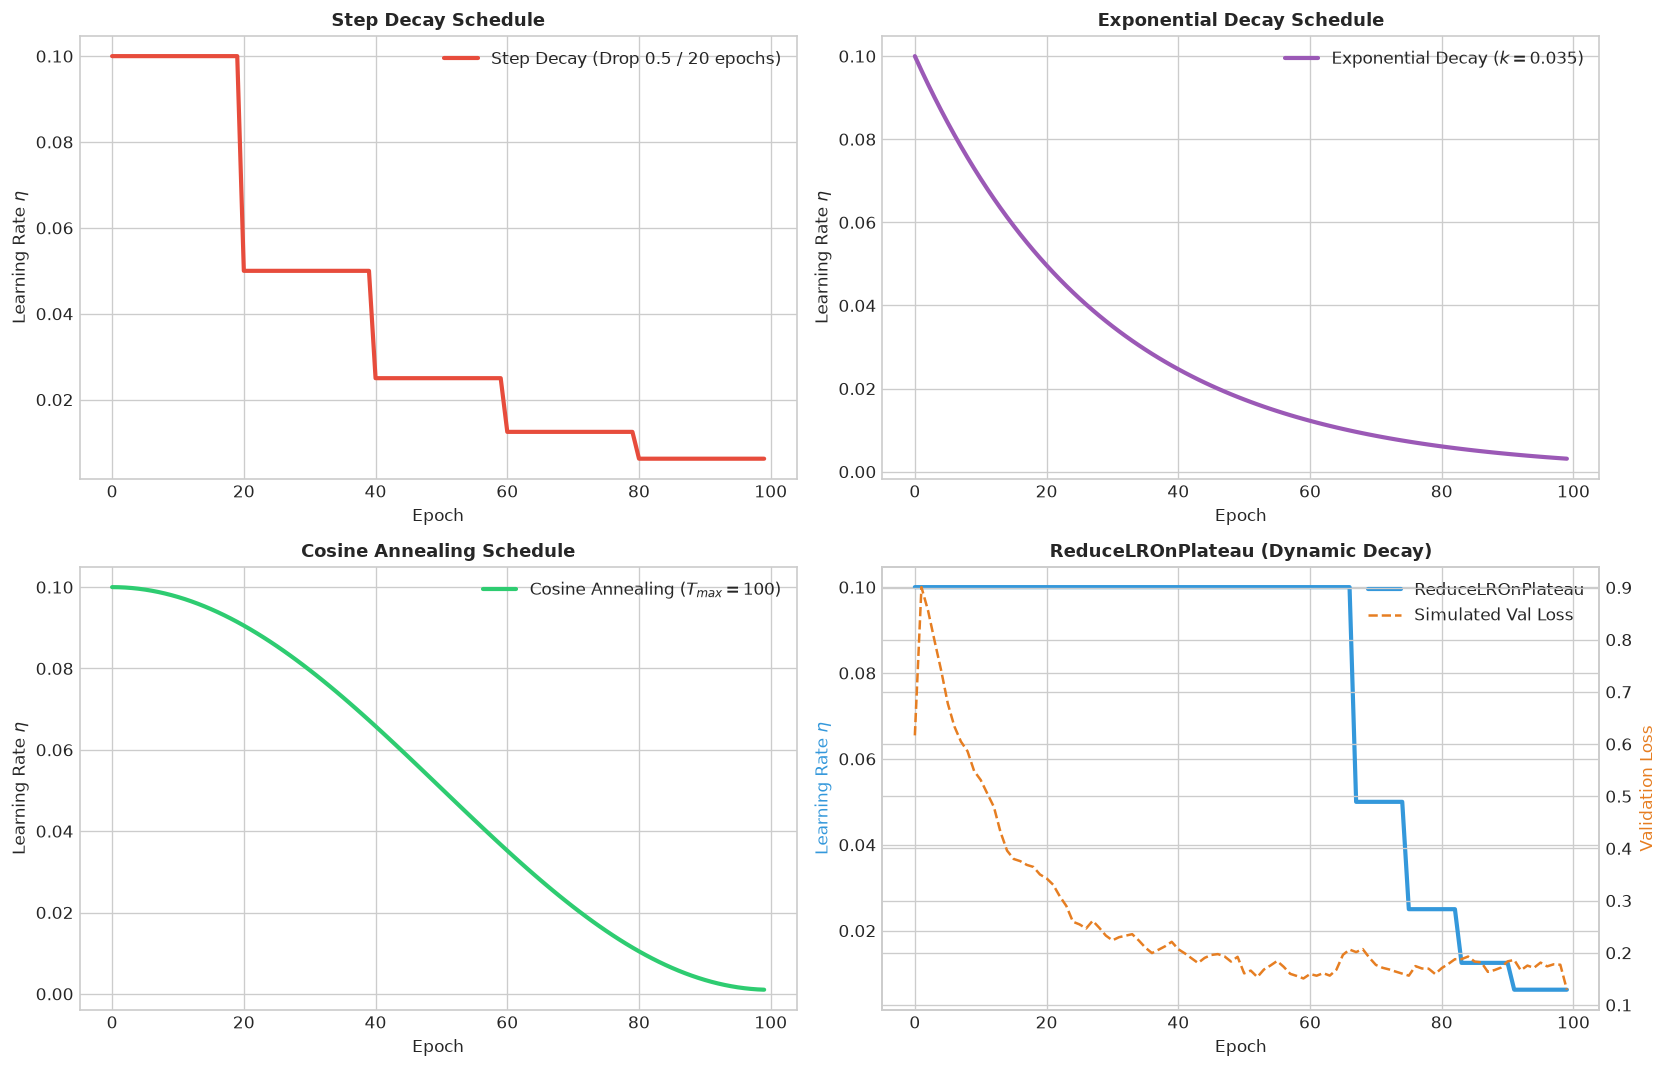

In [9]:
# Section 4 Visualizations: Learning Rate Schedule Curves

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Panel 1: Step Decay
axes[0, 0].plot(epochs_range, lrs_step, color='#e74c3c', linewidth=2.5, label='Step Decay (Drop 0.5 / 20 epochs)')
axes[0, 0].set_title("Step Decay Schedule", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Learning Rate $\eta$")
axes[0, 0].grid(True)
axes[0, 0].legend()

# Panel 2: Exponential Decay
axes[0, 1].plot(epochs_range, lrs_exp, color='#9b59b6', linewidth=2.5, label='Exponential Decay ($k=0.035$)')
axes[0, 1].set_title("Exponential Decay Schedule", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Learning Rate $\eta$")
axes[0, 1].grid(True)
axes[0, 1].legend()

# Panel 3: Cosine Annealing
axes[1, 0].plot(epochs_range, lrs_cosine, color='#2ecc71', linewidth=2.5, label='Cosine Annealing ($T_{max}=100$)')
axes[1, 0].set_title("Cosine Annealing Schedule", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Learning Rate $\eta$")
axes[1, 0].grid(True)
axes[1, 0].legend()

# Panel 4: ReduceLROnPlateau with Simulated Loss
ax_plateau = axes[1, 1]
ax_loss = ax_plateau.twinx()

line1 = ax_plateau.plot(epochs_range, lrs_plateau, color='#3498db', linewidth=2.5, label='ReduceLROnPlateau')
line2 = ax_loss.plot(epochs_range, simulated_val_loss, color='#e67e22', linestyle='--', linewidth=1.5, label='Simulated Val Loss')

ax_plateau.set_title("ReduceLROnPlateau (Dynamic Decay)", fontsize=11, fontweight='bold')
ax_plateau.set_xlabel("Epoch")
ax_plateau.set_ylabel("Learning Rate $\eta$", color='#3498db')
ax_loss.set_ylabel("Validation Loss", color='#e67e22')

# Combine legends for twin axis
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax_plateau.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()


---
## 5. Empirical Comparison on Classification using TensorFlow/Keras

To bridge theoretical understanding with practical application, we evaluate five major optimizers on a multi-class synthetic dataset using **TensorFlow/Keras**:

1. **Standard SGD** (`learning_rate=0.05`)
2. **SGD with Momentum** (`learning_rate=0.05, momentum=0.9`)
3. **RMSprop** (`learning_rate=0.001`)
4. **Adam** (`learning_rate=0.001`)
5. **AdamW** (`learning_rate=0.001, weight_decay=1e-4`)

---

### 🧪 Experimental Controls
- **Dataset**: 1,200 samples, 20 features (12 informative, 4 classes). Pre-split into 80% Train ($N=960$) and 20% Validation ($N=240$). Features standard-scaled.
- **Model Architecture**: Multi-Layer Perceptron (MLP):
  - `Dense(64, activation='relu')`
  - `BatchNormalization()`
  - `Dropout(0.2)`
  - `Dense(32, activation='relu')`
  - `Dense(4, activation='softmax')`
- **Fair Comparison Protocol**: To eliminate weight initialization bias, a master set of initial weights is generated once and loaded into each model instance prior to training.
- **Training Hyperparameters**: 50 Epochs, Batch Size = 32.


In [10]:
# Section 5: Dataset Preparation and TensorFlow Model Training

# 1. Prepare Synthetic Multi-Class Dataset
X_all, y_all = make_classification(
    n_samples=1200, n_features=20, n_informative=12, n_classes=4,
    n_clusters_per_class=2, random_state=42
)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)

# 2. Function to build standard MLP architecture
def create_mlp_model():
    tf.random.set_seed(42)
    return tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(20,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(4, activation='softmax')
    ])

# Save master initial weights to ensure identical starting state
master_model = create_mlp_model()
master_weights = master_model.get_weights()

# 3. Define Optimizers dictionary
optimizers_dict = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.05),
    'SGD + Momentum': tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001),
    'AdamW': tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4)
}

results_history = {}
execution_times = {}

print("Starting Comparative Optimizer Training...")
print("-" * 65)

for name, opt in optimizers_dict.items():
    model = create_mlp_model()
    model.set_weights(master_weights) # Load exact identical weights
    
    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    start_time = time.time()
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=0
    )
    elapsed = time.time() - start_time
    
    results_history[name] = hist.history
    execution_times[name] = elapsed
    
    final_val_acc = hist.history['val_accuracy'][-1] * 100
    final_val_loss = hist.history['val_loss'][-1]
    print(f"[{name:15s}] Completed in {elapsed:.2f}s | Val Acc: {final_val_acc:.2f}% | Val Loss: {final_val_loss:.4f}")

print("-" * 65)
print("Training across all optimizers complete!")


Starting Comparative Optimizer Training...
-----------------------------------------------------------------


[SGD            ] Completed in 3.29s | Val Acc: 83.33% | Val Loss: 0.4092


[SGD + Momentum ] Completed in 2.66s | Val Acc: 81.25% | Val Loss: 0.6182


[RMSprop        ] Completed in 2.68s | Val Acc: 83.33% | Val Loss: 0.4018


[Adam           ] Completed in 2.91s | Val Acc: 83.75% | Val Loss: 0.4064


[AdamW          ] Completed in 2.97s | Val Acc: 83.33% | Val Loss: 0.4053
-----------------------------------------------------------------
Training across all optimizers complete!


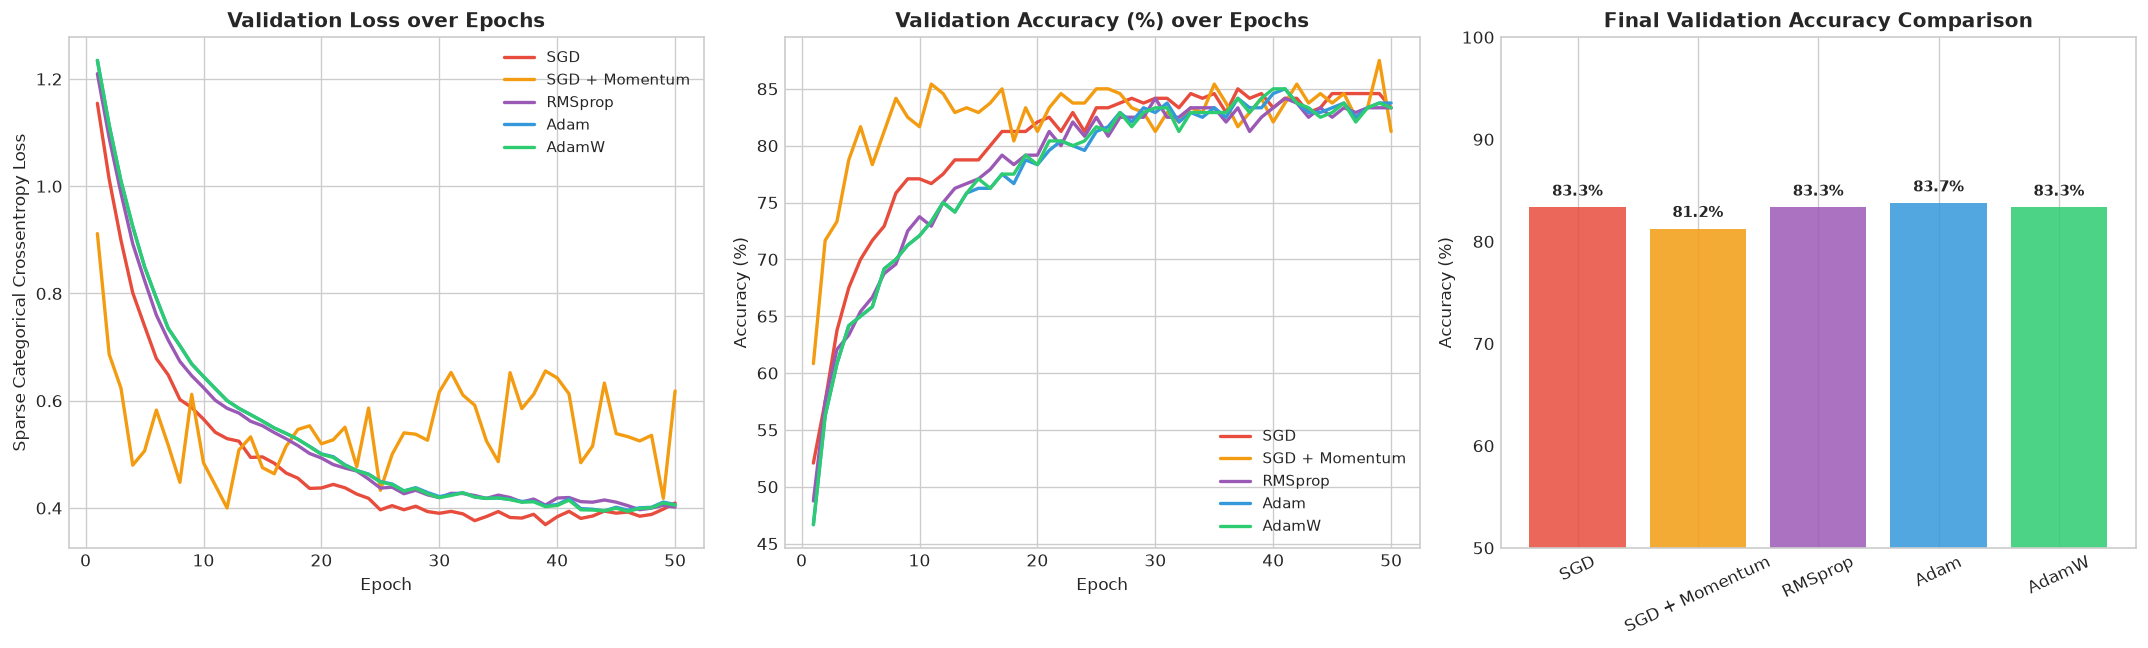


OPTIMIZER PERFORMANCE SUMMARY TABLE


,Optimizer,Final Train Loss,Final Val Loss,Final Train Acc (%),Final Val Acc (%),Epochs to 80% Val Acc,Time Taken (s)
0,SGD,0.1795,0.4092,93.02%,83.33%,16,3.29s
1,SGD + Momentum,0.2030,0.6182,92.29%,81.25%,5,2.66s
2,RMSprop,0.2154,0.4018,92.40%,83.33%,21,2.68s
3,Adam,0.2152,0.4064,92.81%,83.75%,22,2.91s
4,AdamW,0.2133,0.4053,92.81%,83.33%,21,2.97s


In [11]:
# Section 5 Visualizations and Comprehensive Results Table

colors = {
    'SGD': '#e74c3c',
    'SGD + Momentum': '#f39c12',
    'RMSprop': '#9b59b6',
    'Adam': '#3498db',
    'AdamW': '#2ecc71'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Subplot 1: Validation Loss Curves
for name, hist in results_history.items():
    axes[0].plot(range(1, 51), hist['val_loss'], label=name, color=colors[name], linewidth=2)
axes[0].set_title("Validation Loss over Epochs", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse Categorical Crossentropy Loss")
axes[0].legend(fontsize=9)
axes[0].grid(True)

# Subplot 2: Validation Accuracy Curves
for name, hist in results_history.items():
    axes[1].plot(range(1, 51), [acc * 100 for acc in hist['val_accuracy']], label=name, color=colors[name], linewidth=2)
axes[1].set_title("Validation Accuracy (%) over Epochs", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(fontsize=9)
axes[1].grid(True)

# Subplot 3: Final Accuracy Bar Chart
final_accs = [results_history[name]['val_accuracy'][-1] * 100 for name in optimizers_dict.keys()]
bars = axes[2].bar(optimizers_dict.keys(), final_accs, color=[colors[n] for n in optimizers_dict.keys()], alpha=0.85)

for bar in bars:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=9)

axes[2].set_ylim(50, 100)
axes[2].set_title("Final Validation Accuracy Comparison", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Accuracy (%)")
axes[2].tick_params(axis='x', rotation=25)
axes[2].grid(axis='y')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Construct Formatted Summary DataFrame
# ---------------------------------------------------------
summary_data = []
target_acc = 0.80 # Threshold to measure convergence speed

for name, hist in results_history.items():
    # Find epoch where validation accuracy reached target_acc
    val_accs = hist['val_accuracy']
    epochs_to_target = next((i + 1 for i, acc in enumerate(val_accs) if acc >= target_acc), "> 50")
    
    summary_data.append({
        'Optimizer': name,
        'Final Train Loss': f"{hist['loss'][-1]:.4f}",
        'Final Val Loss': f"{hist['val_loss'][-1]:.4f}",
        'Final Train Acc (%)': f"{hist['accuracy'][-1] * 100:.2f}%",
        'Final Val Acc (%)': f"{hist['val_accuracy'][-1] * 100:.2f}%",
        'Epochs to 80% Val Acc': epochs_to_target,
        'Time Taken (s)': f"{execution_times[name]:.2f}s"
    })

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("OPTIMIZER PERFORMANCE SUMMARY TABLE")
print("="*80)
display(df_summary)


---
## 6. Comprehensive Summary & Practitioner's Cheat Sheet

### 💡 Key Takeaways & Guidelines

| Optimizer | Best Suited For | Main Strengths | Known Weaknesses | Recommended Initial $\eta$ |
| :--- | :--- | :--- | :--- | :--- |
| **SGD** | Simple baseline models | Clean convergence properties, low memory | Slow, sensitive to tuning, struggles in ravines | $0.01 - 0.1$ |
| **SGD + Momentum** | CNNs, Computer Vision models (ResNet) | Fast in consistent directions, excellent generalization | Requires fine-tuning of momentum $\gamma$ | $0.01 - 0.05$ |
| **RMSprop** | Recurrent Neural Networks (RNNs, LSTMs) | Handles non-stationary objectives, adaptive scaling | Sensitive to learning rate choice | $0.001$ |
| **Adam** | General Deep Learning, NLP, Transformers | Robust out-of-the-box, fast initial progress | Can suffer from sub-optimal generalization vs SGD | $0.001$ |
| **AdamW** | Modern Transformers (ViT, LLMs, BERT) | Decouples weight decay, superior generalization | Requires tuning weight decay parameter | $0.001 - 0.0003$ |

---

### 🎯 Rules of Thumb for Deep Learning Optimization:
1. **Default Starting Point**: Start with **AdamW** ($\eta = 0.001$, `weight_decay = 1e-4`) or **Adam**. They are robust to noisy gradients and initial scale.
2. **Computer Vision & SOTA Generalization**: For fine-tuning vision networks (e.g. ResNet/ConvNeXt), **SGD with Momentum** ($\gamma = 0.9$) paired with a **Cosine Annealing** schedule often yields slightly higher peak validation accuracy than standard Adam.
3. **Decoupled Weight Decay Matters**: Always prefer **AdamW** over standard **Adam** with L2 weight decay when training deep architectures (especially Transformers and Deep MLPs).
4. **Learning Rate Schedulers**: Always use a learning rate schedule (**Cosine Annealing** or **ReduceLROnPlateau**). Decreasing $\eta$ near the end of training allows the model to settle into tight minima.

---
